# Latest Refresh
## FloodNet NYC Tutorial
Author: Mark Bauer

# Summary
FloodNet refreshes its NYC Open Data datasets roughly every two weeks. In this notebook, we look at the flood events added in the most recent refresh: how many there are, when the flooding happened, and how the new events rank against every event on record. Note that a refresh inserts two kinds of events: floods that occurred during the refresh window, and **late arrivals**, older events that were still in quality assurance (QA) at the previous refresh and were only published now.

# Import Libraries

In [18]:
# Libraries
# Standard library
import json
from datetime import datetime, timedelta
from pathlib import Path

# Third-party
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import polars as pl

# Custom FloodNet functions
import floodnet

In [19]:
# Print versions of packages for reproducibility
libraries = {
    "polars": pl.__version__,
    "matplotlib": matplotlib.__version__,
}

for name, version in libraries.items():
    print(f"{name:10s} {version}")

polars     1.38.1
matplotlib 3.10.8


# Refresh Window
Every row on NYC Open Data carries a hidden `:created_at` timestamp. When we download the data in [00-download-data.ipynb](https://github.com/mebauer/floodnet-nyc-tutorial/blob/main/00-download-data.ipynb), the manifest records two of these timestamps:

- `latest_created_at`: the newest row timestamp as of the download
- `previous_created_at`: what `latest_created_at` was before the most recent refresh

Rows created after `previous_created_at` are the rows the most recent refresh added.

In [20]:
# Flood Events dataset
dataset_id = "aq7i-eu5q"

# Read the watermarks for this dataset from the manifest
manifest = json.loads(Path("data/manifest.json").read_text())["datasets"]
dataset_record = {d["dataset_id"]: d for d in manifest}[dataset_id]

previous_created_at = dataset_record["previous_created_at"]
latest_created_at = dataset_record["latest_created_at"]

print(f"Previous refresh:  {previous_created_at}")
print(f"Latest refresh:    {latest_created_at}")

Previous refresh:  2026-09-01T13:00:14.039Z
Latest refresh:    2026-09-15T13:00:14.878Z


# Download New Flood Events
Because of late arrivals, we report two counts for each refresh:

- **Inserted in this refresh**: every event with `:created_at` after `previous_created_at`
- **Occurred in the refresh window**: the subset whose `flood_start_time` falls between `previous_created_at` and `latest_created_at`

The difference is the **late arrivals**: events that occurred before the window but were still possibly in QA at the previous refresh.

In [21]:
# Flood events published after the previous refresh
new_df = floodnet.download_new_records(dataset_id, since=previous_created_at)

# Refresh window as naive UTC datetimes, to match flood_start_time
window_start = datetime.fromisoformat(previous_created_at).replace(tzinfo=None)
window_end = datetime.fromisoformat(latest_created_at).replace(tzinfo=None)

# New events that started within the refresh window
window_df = new_df.filter(
    pl.col("flood_start_time").is_between(window_start, window_end)
)

print(f"Events inserted in this refresh:     {new_df.height:,}")
print(f"  Occurred in the refresh window:    {window_df.height:,}")
print(f"  Late arrivals (earlier, post-QA):  {new_df.height - window_df.height:,}")
print(f"Counts by unique sensors:            {new_df['sensor_id'].n_unique():,}")

https://data.cityofnewyork.us/resource/aq7i-eu5q.csv?%24%24exclude_system_fields=false&%24where=%3Acreated_at+%3E+%272026-09-01T13%3A00%3A14.039Z%27&%24limit=500000

Events inserted in this refresh:     86
  Occurred in the refresh window:    47
  Late arrivals (earlier, post-QA):  39
Counts by unique sensors:            33


# When Did the New Events Occur?
A refresh adds recent floods as well as late arrivals, older events that only just cleared QA. The date range of `flood_start_time` (UTC) shows which kind of events this batch contains.

In [22]:
# Date range of the new events
new_df.select(
    pl.col("flood_start_time").min().alias("earliest_start"),
    pl.col("flood_start_time").max().alias("latest_start"),
)

earliest_start,latest_start
datetime[μs],datetime[μs]
2023-09-29 07:23:34,2026-09-08 00:14:50


In [23]:
print(f"Inspect late arrivals (earlier, post-QA):  {new_df.height - window_df.height:,} flood events")

previous_created_datetime = datetime.fromisoformat(previous_created_at).replace(tzinfo=None)
(new_df.filter(pl.col("flood_start_time") <= previous_created_datetime)
    .sort(pl.col("flood_start_time"))
    .head(10)
)

Inspect late arrivals (earlier, post-QA):  39 flood events


sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins,duration_above_24_inches_mins,flood_profile_depth_inches,flood_profile_time_secs,created_at
str,str,datetime[μs],datetime[μs],f64,f64,f64,f64,f64,f64,i64,str,str,"datetime[μs, UTC]"
"""BK - Hoyt St/5th St""","""BK-hoyt-st-5th-st-007sk0""",2023-09-29 07:23:34,2023-09-29 20:55:52,9.25,1548936.5,null,812.31,0.0,0.0,0,"""[0.00, 0.79, 0.75, 1.26, 1.34,…","""[0, 63, 126, 252, 314, 378, 44…",2026-09-15 13:00:14.878 UTC
"""BX - Brady Ave/ Muliner Ave""","""BX-brady-ave-muliner-ave-2917g…",2026-08-22 01:30:08,2026-08-22 03:52:08,1.97,1.0,140.99,141.99,0.0,0.0,0,"""[0.00, 1.97, 1.97, 1.97, 1.97,…","""[0, 60, 120, 180, 240, 300, 42…",2026-09-15 13:00:14.878 UTC
"""Q - Huxley St/Craft Ave""","""Q-craft-ave-huxley-st-3-2wiemc""",2026-08-23 12:42:45,2026-08-23 12:55:45,1.97,5.0,8.01,13.01,0.0,0.0,0,"""[0.00, 0.75, 1.50, 1.54, 1.81,…","""[0, 60, 120, 180, 240, 300, 36…",2026-09-15 13:00:14.878 UTC
"""Q - Huxley St/Craft Ave""","""Q-craft-ave-huxley-st-3-2wiemc""",2026-08-24 02:36:37,2026-08-24 04:20:38,2.05,78.03,26.0,104.02,0.0,0.0,0,"""[0.00, 0.00, 0.43, 0.47, 0.59,…","""[0, 60, 120, 180, 240, 302, 36…",2026-09-15 13:00:14.878 UTC
"""Q - Huxley St/Craft Ave""","""Q-craft-ave-huxley-st-3-2wiemc""",2026-08-24 04:31:39,2026-08-24 04:49:39,1.54,13.0,5.0,18.0,0.0,0.0,0,"""[0.00, 0.47, 0.55, 0.55, 0.94,…","""[0, 60, 120, 180, 240, 300, 36…",2026-09-15 13:00:14.878 UTC
"""BK - Brighton 6th St/Ocean Vie…","""BK-brighton-6th-st-ocean-view-…",2026-08-24 10:27:10,2026-08-24 12:05:09,2.48,17.0,80.98,97.98,0.0,0.0,0,"""[0.51, 1.14, 1.26, 1.26, 2.05,…","""[0, 180, 240, 300, 360, 420, 4…",2026-09-15 13:00:14.878 UTC
"""Q - Brookville Blvd/ Snake Rd …","""Q-brookville-blvd-149th-ave-3-…",2026-08-24 10:43:54,2026-08-24 11:52:55,0.67,27.0,42.0,69.0,0.0,0.0,0,"""[0.00, 0.63, 0.63, 0.63, 0.63,…","""[0, 1380, 1440, 1500, 1560, 16…",2026-09-15 13:00:14.878 UTC
"""BX - Tibbett Ave/W 234th St""","""BX-w-234th-st-tibbett-ave-2cak…",2026-08-27 14:00:38,2026-08-27 15:45:37,1.34,22.0,82.98,104.98,0.0,0.0,0,"""[0.00, 1.34, 1.34, 1.34, 1.26,…","""[0, 1320, 1380, 1440, 1500, 15…",2026-09-15 13:00:14.878 UTC
"""SI - Ridgewood Ave/Arthur Kill…","""SI-ridgewood-ave-arthur-kill-r…",2026-08-27 16:42:57,2026-08-27 17:50:56,11.65,28.0,39.98,67.98,54.86,0.0,0,"""[0.00, 0.00, 0.83, 1.85, 3.19,…","""[0, 60, 120, 180, 360, 480, 54…",2026-09-15 13:00:14.878 UTC


## New Events per Day
Counting events by start date shows which storm days produced them. The chart covers only the refresh window, from `previous_created_at` to `latest_created_at`, so late arrivals are left out; they're listed in the tables above. Earlier days are not plotted because most of their events were published in previous refreshes, and showing only their late arrivals would make those days look drier than they were. Counts for the last few days of the window may still grow, as events still in QA arrive in the next refresh.

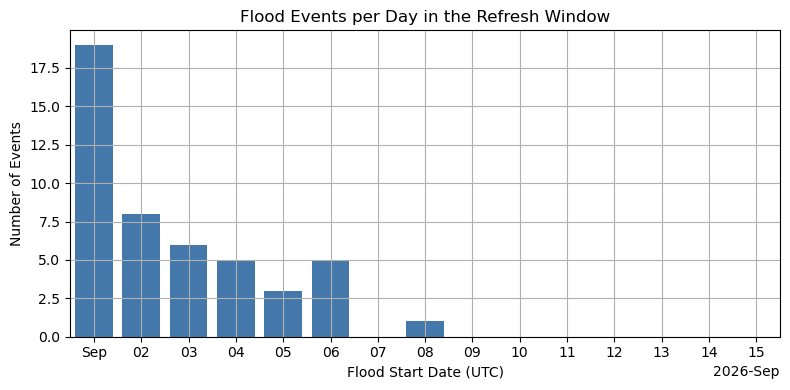

In [24]:
# Count new events per day within the refresh window
daily_df = (
    window_df.group_by(pl.col("flood_start_time").dt.date().alias("date"))
    .len()
    .sort("date")
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(daily_df["date"], daily_df["len"], color=floodnet.COLORBLIND_PALETTE[0])

ax.set_title("Flood Events per Day in the Refresh Window")
ax.set_xlabel("Flood Start Date (UTC)")
ax.set_ylabel("Number of Events")

# Show every day of the refresh window, including days without floods
first_day = datetime.combine(window_start.date(), datetime.min.time())
last_day = datetime.combine(window_end.date(), datetime.min.time())
ax.set_xlim(first_day - timedelta(hours=12), last_day + timedelta(hours=12))

locator = mdates.DayLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
ax.grid(True)

fig.tight_layout()

# Where Did the New Events Occur?
We join the new events to the sensor metadata to count them by borough and by whether the sensor is tidally influenced. Tidal sensors flood with high tides, while non-tidal sensors flood mostly from rainfall.

In [25]:
# Read in sensor metadata
metadata_df = pl.read_csv("data/sensor-metadata.csv", try_parse_dates=True)

# Attach borough and tidal influence to each new event
new_meta_df = new_df.join(
    metadata_df.select("sensor_id", "borough", "tidally_influenced"),
    on="sensor_id",
    how="left",
)

# New events by borough
new_meta_df.group_by("borough").len().sort("len", descending=True)

borough,len
str,u32
"""Queens""",32
"""Staten Island""",24
"""Bronx""",22
"""Brooklyn""",8


In [26]:
# New events by tidal influence
new_meta_df.group_by("tidally_influenced").len().sort("len", descending=True)

tidally_influenced,len
str,u32
"""Yes""",49
"""No""",37


## Sensors with the Most New Events
Frequency and depth tell different stories: the sensors that flooded most often are not always the ones that flooded deepest. Note that some locations have more than one sensor, e.g. `Q - Beach 84 St` and `Q - Beach 84 St (2)`, and these are counted separately.

In [27]:
# Top 10 sensors by number of new events
(new_meta_df.group_by("sensor_name", "borough", "tidally_influenced")
    .agg(
        pl.len().alias("new_events"),
        pl.col("max_depth_inches").max().alias("max_depth_inches"),
    )
    .sort("new_events", descending=True)
    .head(10)
)

sensor_name,borough,tidally_influenced,new_events,max_depth_inches
str,str,str,u32,f64
"""Q - Beach 84 St""","""Queens""","""Yes""",11,6.3
"""BX - Ditmars St/Hunter Ave 2""","""Bronx""","""Yes""",10,9.29
"""Q - Beach 84 St (2)""","""Queens""","""Yes""",7,6.02
"""BX - Tibbett Ave/W 234th St""","""Bronx""","""No""",6,1.54
"""Q - Norton Dr/ Westbourne Ave""","""Queens""","""Yes""",4,2.4
"""BK - Brighton 6th St/Ocean Vie…","""Brooklyn""","""No""",4,2.48
"""SI - Boundary Ave/Hamden Ave""","""Staten Island""","""Yes""",3,10.91
"""Q - Huxley St/Craft Ave""","""Queens""","""No""",3,2.05
"""SI - Bay St/Baltic St""","""Staten Island""","""No""",2,4.92


# How Do the New Events Rank?
Below, we rank every flood event on record by max depth and then keep only the new ones. A rank of 1 means this refresh brought in the deepest flood event FloodNet has ever measured.

Flood events have no ID column, so we match on `sensor_id` and `flood_start_time`, which together identify an event.

In [28]:
# Read in all flood events
path = "data/flood-events.csv"
events_df = pl.read_csv(
    path,
    # some columns have sparse data, need to expand the row count
    infer_schema_length=100_000,
    try_parse_dates=True,
)

print(f"Events on record: {events_df.height:,}")

Events on record: 3,269


In [29]:
# Rank all flood events by max depth (1 = deepest on record)
ranked_df = events_df.with_columns(
    pl.col("max_depth_inches")
        .rank(method="min", descending=True)
        .cast(pl.Int32)
        .alias("depth_rank")
)

# An event is identified by its sensor and start time
event_key = ["sensor_id", "flood_start_time"]

# Columns in preview table
preview_cols = [
    "sensor_name", "flood_start_time", "max_depth_inches", "duration_mins"
]

# Keep only the newly added events
new_ranked_df = (
    ranked_df.join(new_df.select(event_key), on=event_key, how="inner")
    .sort("depth_rank")
)

new_ranked_df.select(["depth_rank"] + preview_cols).head(10)

depth_rank,sensor_name,flood_start_time,max_depth_inches,duration_mins
i32,str,datetime[μs],f64,f64
184,"""SI - Minthorne St/ Victory Blv…",2026-09-01 22:24:42,13.43,177.12
267,"""SI - Ridgewood Ave/Arthur Kill…",2026-08-27 16:42:57,11.65,67.98
317,"""SI - Boundary Ave/Hamden Ave""",2026-08-27 16:50:10,10.91,482.93
357,"""SI - Minthorne St/ Victory Blv…",2026-08-27 20:25:57,10.24,175.0
379,"""SI - Grimsby St/ Mapleton Ave""",2026-08-27 16:57:04,10.0,246.97
439,"""BX - Ditmars St/Hunter Ave 2""",2026-09-02 18:02:40,9.29,196.99
442,"""BK - Hoyt St/5th St""",2023-09-29 07:23:34,9.25,812.31
467,"""SI - Cassidy Pl/Lafayette Ave""",2026-08-27 20:24:15,8.98,43.99
468,"""SI - Bay St/Front St""",2026-09-01 22:30:40,8.94,115.96


# New Flood Profiles
We plot the depth-over-time profile of every event that started within the refresh window, the same events as the per-day chart above. Late arrivals are left out for the same reason. Each reading's timestamp is the event's start time plus its elapsed seconds, so storm days show up as clusters of events. Lines are colored by borough. Times are in UTC.

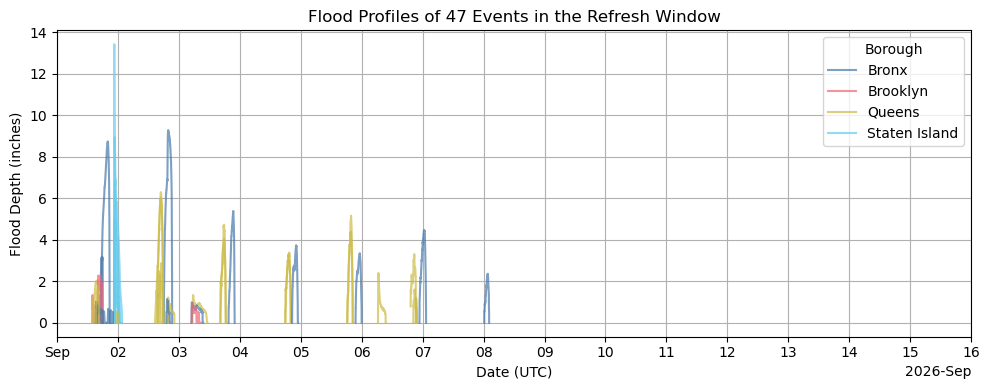

In [30]:
# The profile columns are stored as JSON strings in the CSV, decode them to lists
# Attach each event's borough from the sensor metadata
profiles_df = window_df.with_columns(
    pl.col("flood_profile_time_secs").str.json_decode(pl.List(pl.Float64)),
    pl.col("flood_profile_depth_inches").str.json_decode(pl.List(pl.Float64)),
).join(
    metadata_df.select("sensor_id", "borough"),
    on="sensor_id",
    how="left",
)

# One row per reading, stamped with its date and time
readings_df = (
    profiles_df.select(event_key + ["borough", "flood_profile_time_secs", "flood_profile_depth_inches"])
    .explode("flood_profile_time_secs", "flood_profile_depth_inches")
    .with_columns(
        (
            pl.col("flood_start_time")
            + pl.duration(seconds=pl.col("flood_profile_time_secs"))
        ).alias("timestamp")
    )
)

# One color per borough, fixed across all boroughs so colors stay stable between refreshes
boroughs = sorted(metadata_df["borough"].drop_nulls().unique())
borough_colors = dict(zip(boroughs, floodnet.COLORBLIND_PALETTE))

fig, ax = plt.subplots(figsize=(10, 4))

# One line per event, colored by borough
for (sensor_id, start, borough), event_df in readings_df.group_by(
    event_key + ["borough"], maintain_order=True
):
    ax.plot(
        event_df["timestamp"],
        event_df["flood_profile_depth_inches"],
        color=borough_colors[borough],
        alpha=0.7,
        label=borough,
    )

# One legend entry per borough in the plot
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(
    [by_label[b] for b in boroughs if b in by_label],
    [b for b in boroughs if b in by_label],
    title="Borough",
)

ax.set_title(f"Flood Profiles of {profiles_df.height} Events in the Refresh Window")
ax.set_xlabel("Date (UTC)")
ax.set_ylabel("Flood Depth (inches)")

# One tick per day at midnight, label centered on its tick,
# so each day's floods sit between its gridline and the next
locator = mdates.DayLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
ax.grid(True)

# Show every day of the refresh window, as in the per-day chart
ax.set_xlim(first_day, last_day + timedelta(days=1))

fig.tight_layout()

# Deepest New Event
We plot the flood profile (depth over time) of the deepest newly added event. Times are in UTC.

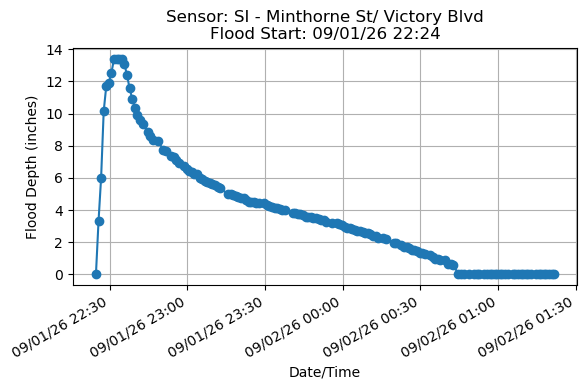

In [31]:
# Top ranked new event
fig, ax = floodnet.plot_flood_event(
    new_ranked_df.head(1),
    start_col="flood_start_time",
)

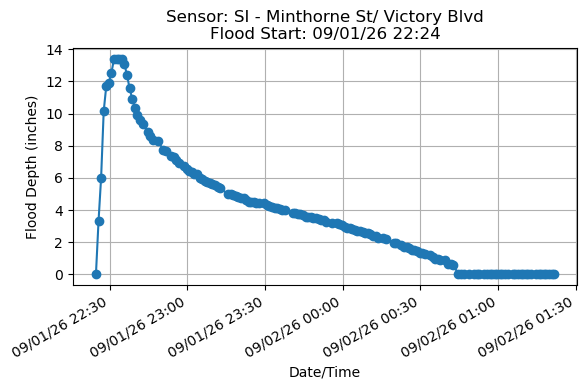

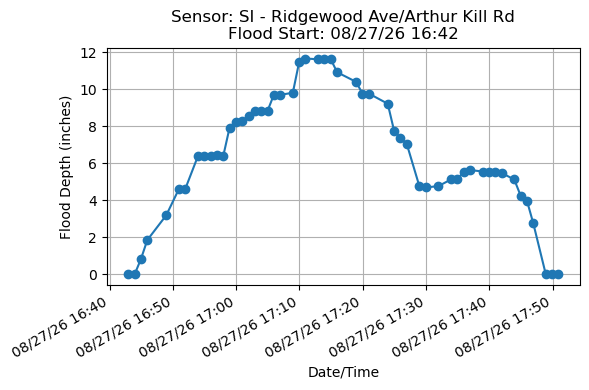

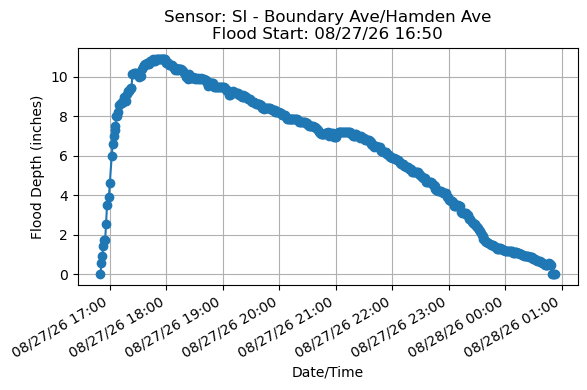

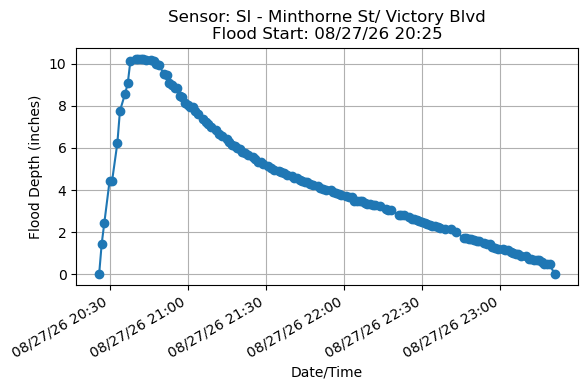

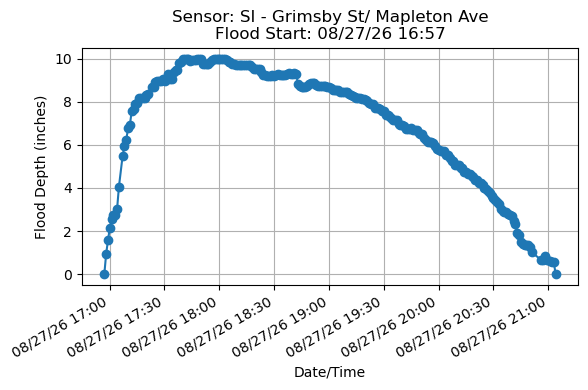

In [32]:
# Top five max depths new events
top5 = new_ranked_df.head(5)
for i in range(top5.height):
    fig, ax = floodnet.plot_flood_event(top5.slice(i, 1), start_col="flood_start_time")

To refresh the data, rerun [00-download-data.ipynb](https://github.com/mebauer/floodnet-nyc-tutorial/blob/main/00-download-data.ipynb). For rankings across every event and sensor, see [02-sensor-rankings.ipynb](https://github.com/mebauer/floodnet-nyc-tutorial/blob/main/02-sensor-rankings.ipynb).